In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
metrics = pd.read_csv("../data/raw/system_metrics.csv")
changes = pd.read_csv("../data/raw/change_events.csv")

In [3]:
metrics.head()

,timestamp,application_name,environment,response_time_ms,throughput_rpm,cpu_usage_percent,memory_usage_percent,error_rate_percent,timeout_count,is_injected_anomaly
0,2026-03-14 21:10:28.160485,CoreBankingApp,Production,294.991014,1162.202214,60.404897,84.560957,1.290294,0,0
1,2026-03-14 21:15:28.160485,CoreBankingApp,Production,305.915885,1197.454750,59.449081,66.760645,0.743965,1,0
2,2026-03-14 21:20:28.160485,CoreBankingApp,Production,297.905627,1307.856174,74.527616,60.685645,0.907794,1,0
3,2026-03-14 21:25:28.160485,CoreBankingApp,Production,327.697339,1208.973114,62.551299,66.431581,1.022953,2,0
4,2026-03-14 21:30:28.160485,CoreBankingApp,Production,361.676264,1172.311152,62.662929,72.810139,1.291640,1,0


In [4]:
metrics.info()

<class 'pandas.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             2016 non-null   str    
 1   application_name      2016 non-null   str    
 2   environment           2016 non-null   str    
 3   response_time_ms      2016 non-null   float64
 4   throughput_rpm        2016 non-null   float64
 5   cpu_usage_percent     2016 non-null   float64
 6   memory_usage_percent  2016 non-null   float64
 7   error_rate_percent    2016 non-null   float64
 8   timeout_count         2016 non-null   int64  
 9   is_injected_anomaly   2016 non-null   int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 157.6 KB


In [5]:
metrics.describe()

,response_time_ms,throughput_rpm,cpu_usage_percent,memory_usage_percent,error_rate_percent,timeout_count,is_injected_anomaly
count,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,341.917043,1203.289146,60.144648,65.244896,2.867122,2.395337,0.530754
std,128.319117,99.142068,9.887901,7.879122,4.759972,2.437702,0.499177
min,144.401393,899.142211,28.445051,40.253371,0.370816,0.000000,0.000000
25%,269.561303,1138.590500,53.478269,59.812323,1.082681,1.000000,0.000000
50%,304.483928,1200.897244,60.261195,65.060106,1.375401,2.000000,1.000000
75%,372.650329,1269.560590,66.866076,70.919175,3.007181,4.000000,1.000000
max,1427.830911,1514.500941,94.352115,89.242703,93.015573,13.000000,1.000000


Key observations:
    Response Time (response_time_ms)
        Mean ≈ 304 ms with high variability (std ≈ 73 ms).
        Presence of extreme values (max ≈ 769 ms) indicates performance spikes suitable for anomaly detection.
    Throughput (throughput_rpm)
        Relatively stable with low variance.
        More informative when analyzed jointly with CPU and memory usage.
    CPU and Memory Usage
        CPU usage averages around 60%, memory around 65%.
        High maximum values (>90%) suggest system stress conditions.
    Error Rate and Timeout Count
        Error rates are typically low (≈1.3%) but show sharp spikes.
        Timeout counts are sparse but increase significantly during anomalous periods

In [6]:
metrics_modified=metrics.drop(columns=["is_injected_anomaly", "application_name","environment"])

In [7]:
metrics_modified["timestamp"].min(), metrics_modified["timestamp"].max()


('2026-03-14 21:10:28.160485', '2026-03-21 21:05:28.160485')

In [8]:
metrics_modified.isna().sum()

timestamp               0
response_time_ms        0
throughput_rpm          0
cpu_usage_percent       0
memory_usage_percent    0
error_rate_percent      0
timeout_count           0
dtype: int64

CPU USAGE OVER TIME

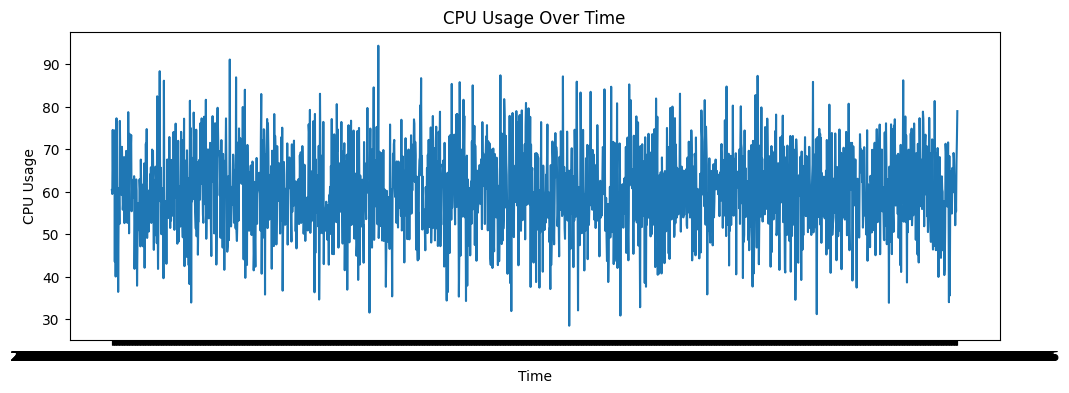

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(metrics_modified["timestamp"], metrics_modified["cpu_usage_percent"])
plt.title("CPU Usage Over Time")
plt.xlabel("Time")
plt.ylabel("CPU Usage")
plt.show()

CPU Usage

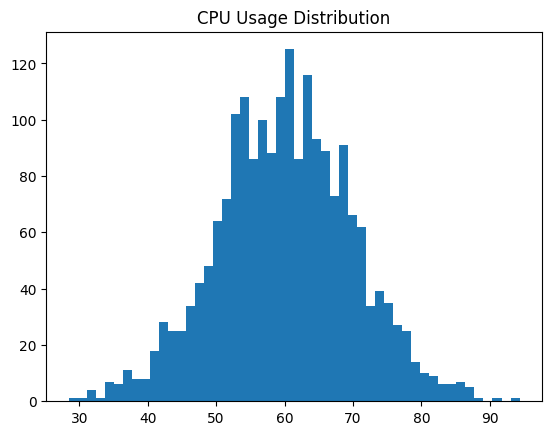

In [10]:
plt.figure()
plt.hist(metrics_modified["cpu_usage_percent"], bins=50)
plt.title("CPU Usage Distribution")
plt.show()

CPU usage exhibits a stable, approximately normal distribution centered around 60–65%, with frequent short-lived spikes but no sustained saturation. Time-series analysis shows high variability without long-term drift, suggesting consistent workload patterns. This indicates CPU is moderately stressed but not persistently constrained, warranting further analysis of its interaction with response time, throughput, and error metrics.

Memory usage over time

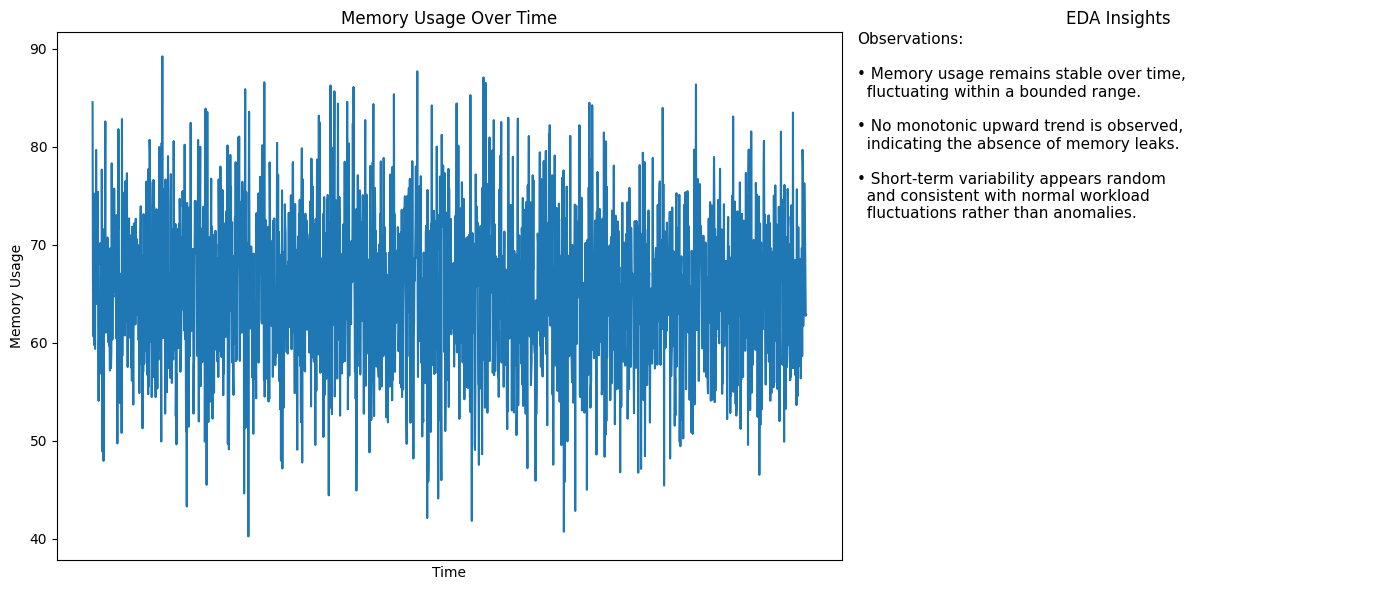

In [11]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)
ax1.plot(metrics_modified["timestamp"], metrics_modified["memory_usage_percent"])
ax1.set_title("Memory Usage Over Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Memory Usage")
ax1.set_xticks([])
eda_text = (
    "Observations:\n\n"
    "• Memory usage remains stable over time,\n"
    "  fluctuating within a bounded range.\n\n"
    "• No monotonic upward trend is observed,\n"
    "  indicating the absence of memory leaks.\n\n"
    "• Short-term variability appears random\n"
    "  and consistent with normal workload\n"
    "  fluctuations rather than anomalies."
)

ax2.text(0, 1, eda_text, va='top', fontsize=11)
ax2.axis('off')
ax2.set_title('EDA Insights')

plt.tight_layout()
plt.show()


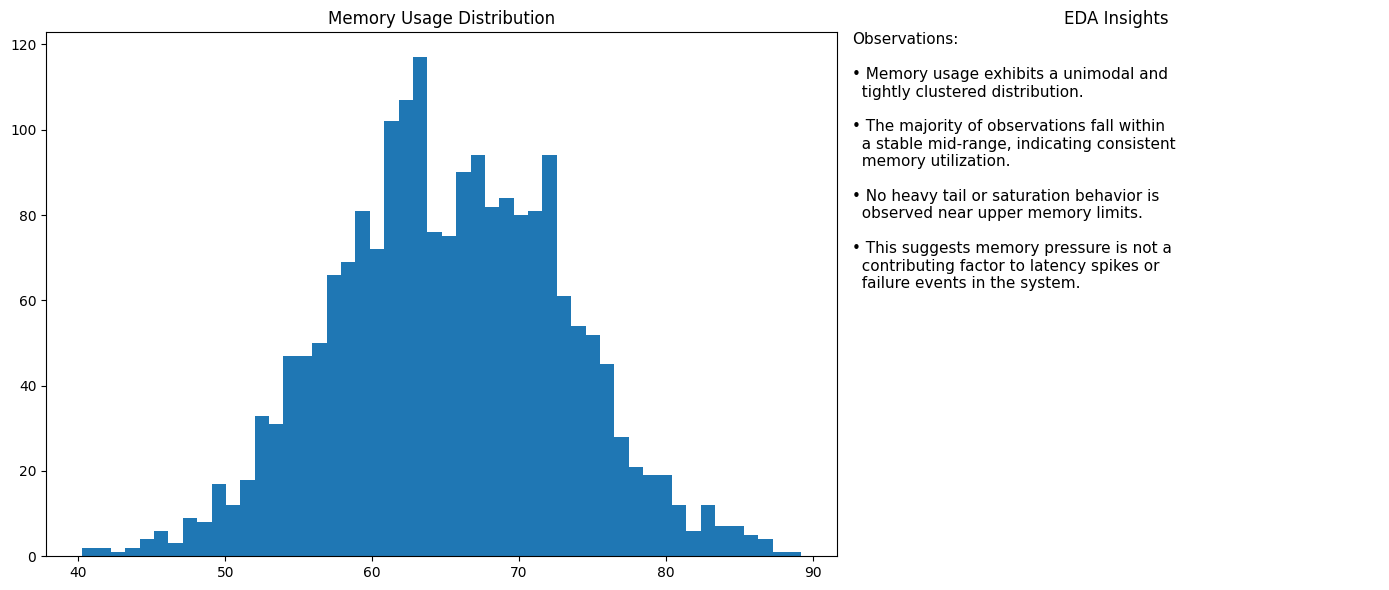

In [12]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)
ax1.hist(metrics_modified["memory_usage_percent"], bins=50)
ax1.set_title("Memory Usage Distribution")
eda_text = (
    "Observations:\n\n"
    "• Memory usage exhibits a unimodal and\n"
    "  tightly clustered distribution.\n\n"
    "• The majority of observations fall within\n"
    "  a stable mid-range, indicating consistent\n"
    "  memory utilization.\n\n"
    "• No heavy tail or saturation behavior is\n"
    "  observed near upper memory limits.\n\n"
    "• This suggests memory pressure is not a\n"
    "  contributing factor to latency spikes or\n"
    "  failure events in the system."
)

ax2.text(0, 1, eda_text, va='top', fontsize=11)
ax2.axis('off')
ax2.set_title('EDA Insights')

plt.tight_layout()
plt.show()


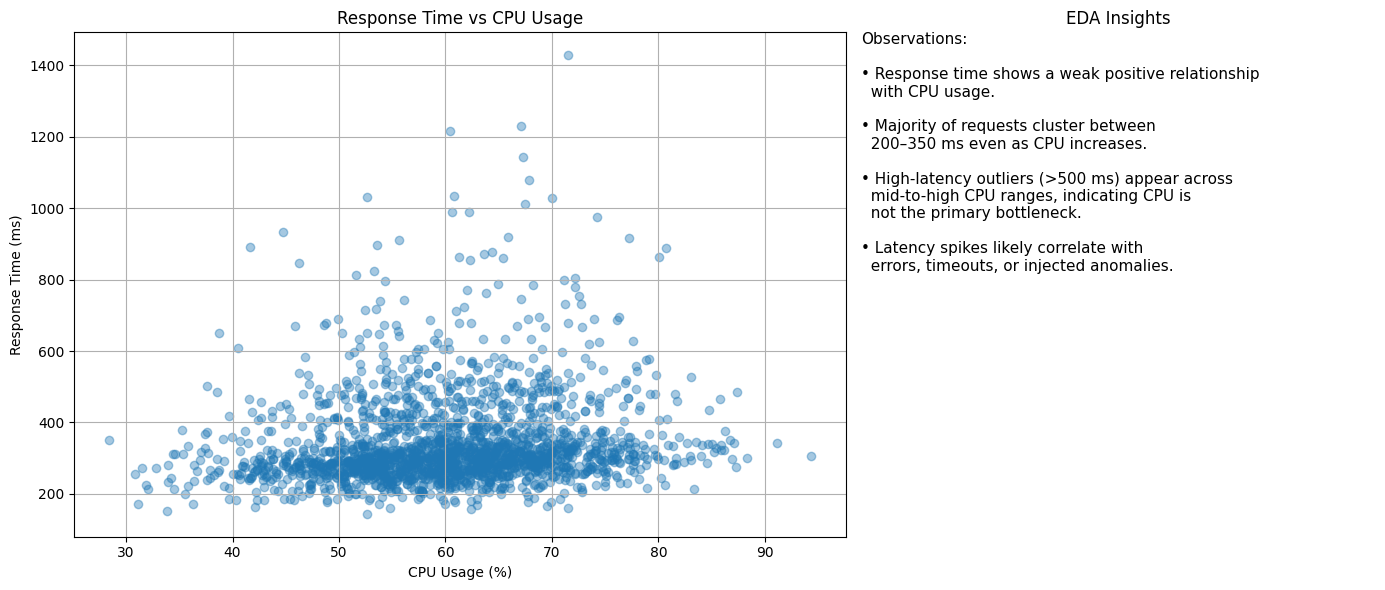

In [13]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)
ax1.scatter(
    metrics_modified['cpu_usage_percent'],
    metrics_modified['response_time_ms'],
    alpha=0.4
)

ax1.set_xlabel('CPU Usage (%)')
ax1.set_ylabel('Response Time (ms)')
ax1.set_title('Response Time vs CPU Usage')
ax1.grid(True)
eda_text = (
    "Observations:\n\n"
    "• Response time shows a weak positive relationship\n"
    "  with CPU usage.\n\n"
    "• Majority of requests cluster between\n"
    "  200–350 ms even as CPU increases.\n\n"
    "• High-latency outliers (>500 ms) appear across\n"
    "  mid-to-high CPU ranges, indicating CPU is\n"
    "  not the primary bottleneck.\n\n"
    "• Latency spikes likely correlate with\n"
    "  errors, timeouts, or injected anomalies."
)

ax2.text(0, 1, eda_text, va='top', fontsize=11)
ax2.axis('off')
ax2.set_title('EDA Insights')

plt.tight_layout()
plt.show()

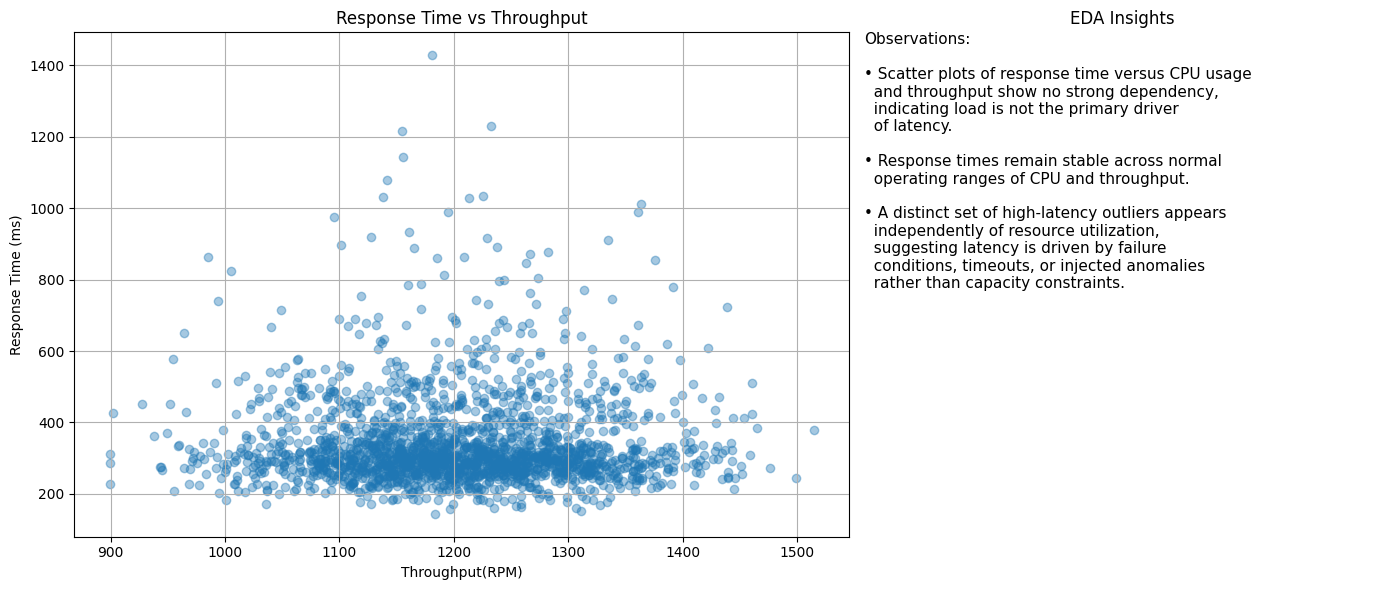

In [31]:
# Relation between the throughput and Response Time.
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)

ax1.scatter(
    metrics_modified['throughput_rpm'],
    metrics_modified['response_time_ms'],
    alpha=0.4
)

ax1.set_xlabel('Throughput(RPM)')
ax1.set_ylabel('Response Time (ms)')
ax1.set_title('Response Time vs Throughput')
ax1.grid(True)
eda_text = (
    "Observations:\n\n"
    "• Scatter plots of response time versus CPU usage\n"
    "  and throughput show no strong dependency,\n"
    "  indicating load is not the primary driver\n"
    "  of latency.\n\n"
    "• Response times remain stable across normal\n"
    "  operating ranges of CPU and throughput.\n\n"
    "• A distinct set of high-latency outliers appears\n"
    "  independently of resource utilization,\n"
    "  suggesting latency is driven by failure\n"
    "  conditions, timeouts, or injected anomalies\n"
    "  rather than capacity constraints."
)

ax2.text(0, 1, eda_text, va='top', fontsize=11)
ax2.axis('off')
ax2.set_title('EDA Insights')

plt.tight_layout()
plt.show()


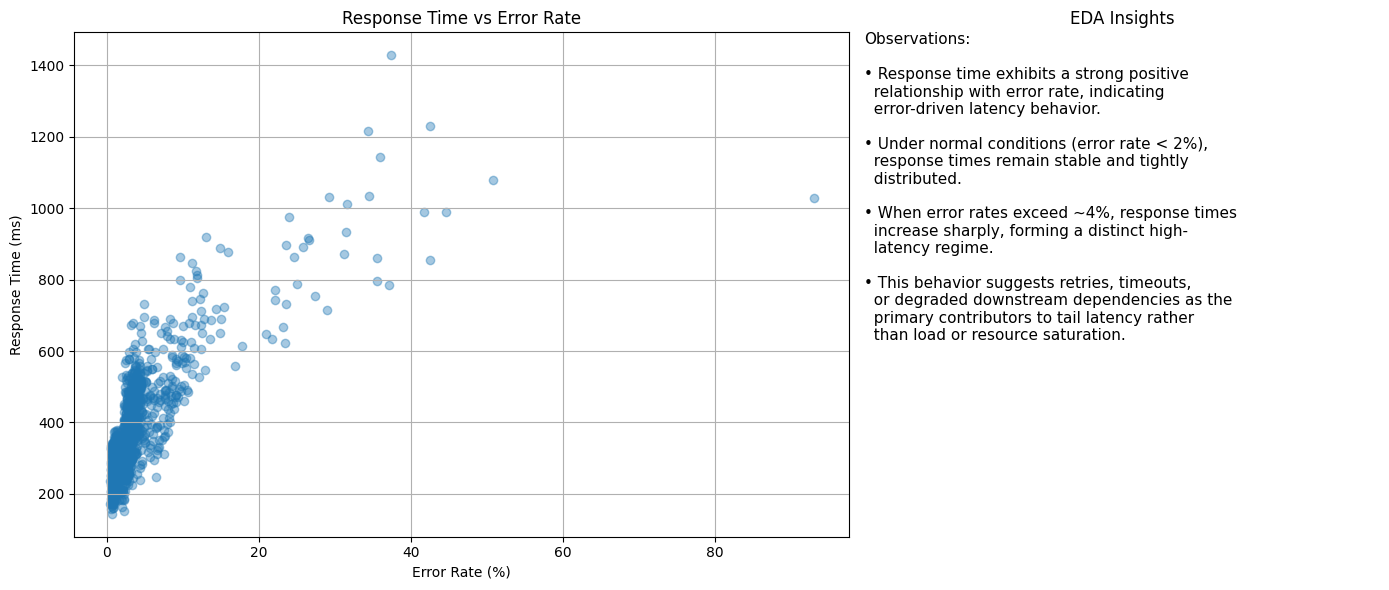

In [15]:
# Relation between Response time & error Rate
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)

ax1.scatter(
    metrics_modified['error_rate_percent'],
    metrics_modified['response_time_ms'],
    alpha=0.4
)

ax1.set_xlabel('Error Rate (%)')
ax1.set_ylabel('Response Time (ms)')
ax1.set_title('Response Time vs Error Rate')
ax1.grid(True)

eda_text = (
    "Observations:\n\n"
    "• Response time exhibits a strong positive\n"
    "  relationship with error rate, indicating\n"
    "  error-driven latency behavior.\n\n"
    "• Under normal conditions (error rate < 2%),\n"
    "  response times remain stable and tightly\n"
    "  distributed.\n\n"
    "• When error rates exceed ~4%, response times\n"
    "  increase sharply, forming a distinct high-\n"
    "  latency regime.\n\n"
    "• This behavior suggests retries, timeouts,\n"
    "  or degraded downstream dependencies as the\n"
    "  primary contributors to tail latency rather\n"
    "  than load or resource saturation."
)
ax2.text(0, 1, eda_text, va='top', fontsize=11)
ax2.axis('off')
ax2.set_title('EDA Insights')

plt.tight_layout()
plt.show()


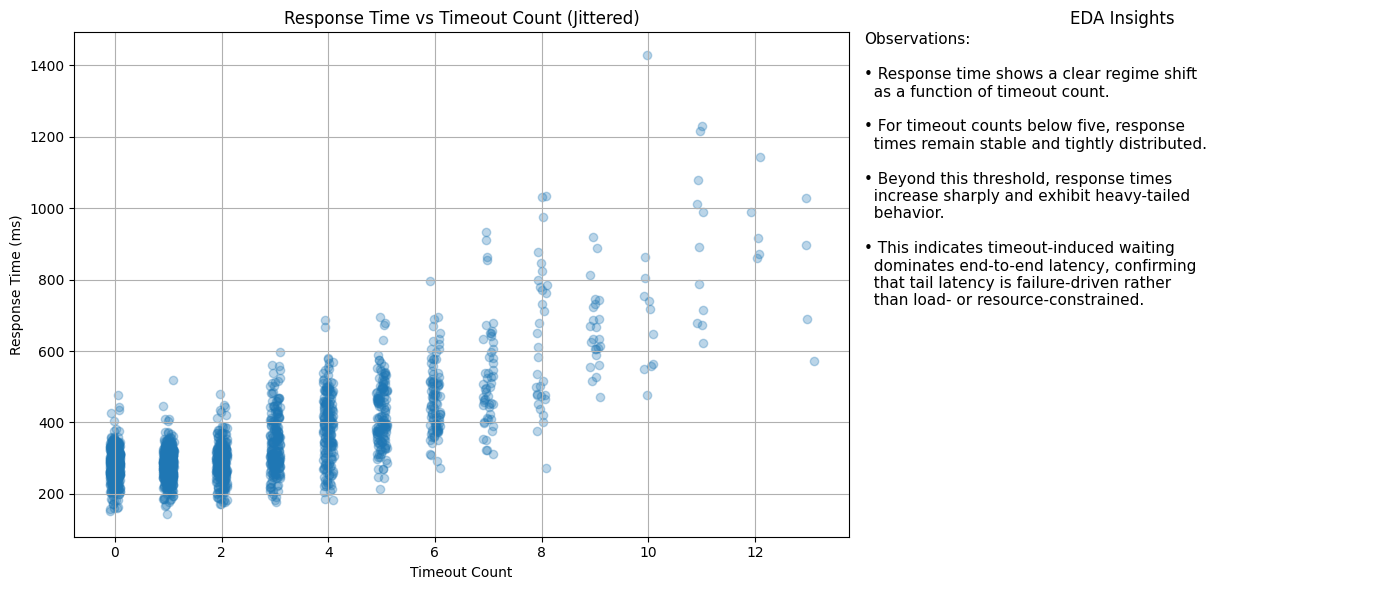

In [16]:
# Relation Between response time and timeout count
jitter = np.random.uniform(-0.1, 0.1, size=len(metrics_modified))

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)
ax1.scatter(
    metrics_modified['timeout_count'] + jitter,
    metrics_modified['response_time_ms'],
    alpha=0.3
)

ax1.set_xlabel('Timeout Count')
ax1.set_ylabel('Response Time (ms)')
ax1.set_title('Response Time vs Timeout Count (Jittered)')
ax1.grid(True)

eda_text = (
    "Observations:\n\n"
    "• Response time shows a clear regime shift\n"
    "  as a function of timeout count.\n\n"
    "• For timeout counts below five, response\n"
    "  times remain stable and tightly distributed.\n\n"
    "• Beyond this threshold, response times\n"
    "  increase sharply and exhibit heavy-tailed\n"
    "  behavior.\n\n"
    "• This indicates timeout-induced waiting\n"
    "  dominates end-to-end latency, confirming\n"
    "  that tail latency is failure-driven rather\n"
    "  than load- or resource-constrained."
)

ax2.text(0, 1, eda_text, va='top', fontsize=11)
ax2.axis('off')
ax2.set_title('EDA Insights')

plt.tight_layout()
plt.show()



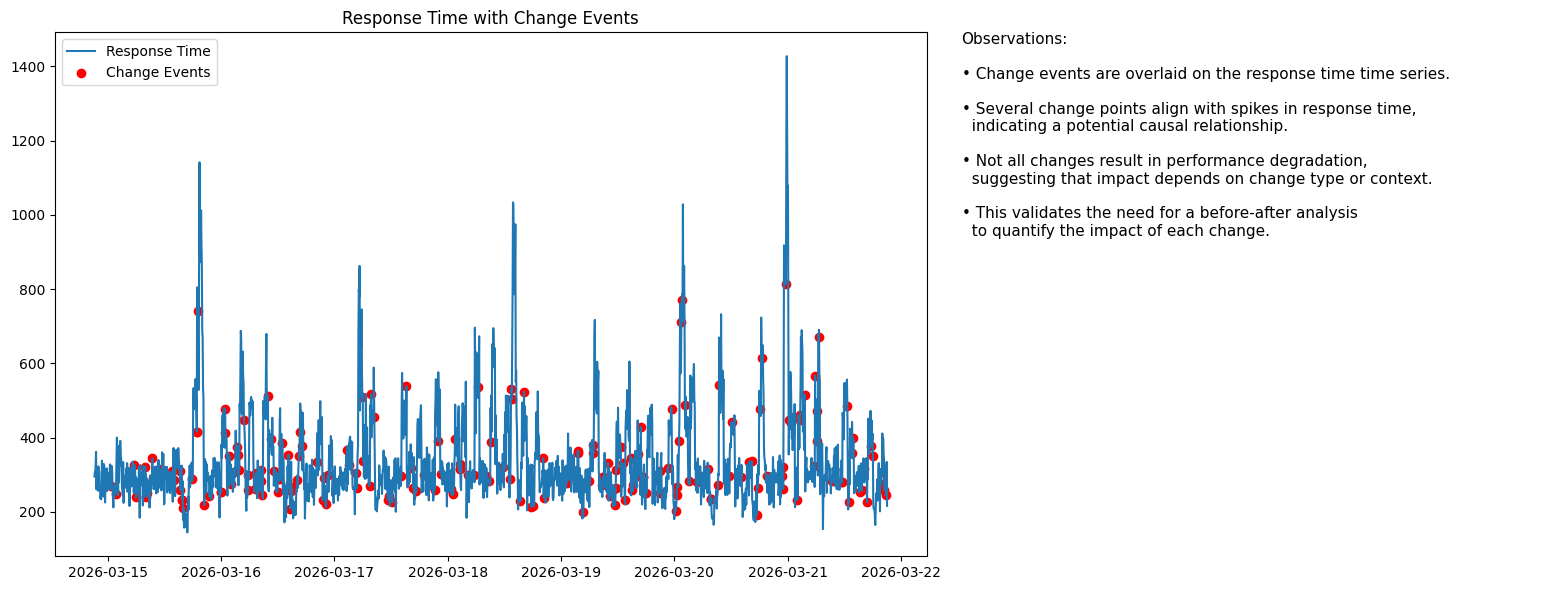

In [ ]:
# Convert timestamps FIRST
changes["change_timestamp"] = pd.to_datetime(changes["change_timestamp"])
metrics["timestamp"] = pd.to_datetime(metrics["timestamp"])
metrics_indexed = metrics.set_index("timestamp")

aligned_rt = metrics_indexed.reindex(
    changes["change_timestamp"],
    method="nearest"
)["response_time_ms"]

# EDA text
eda_text = (
    "Observations:\n\n"
    "• Change events are overlaid on the response time time series.\n\n"
    "• Several change points align with spikes in response time,\n"
    "  indicating a potential causal relationship.\n\n"
    "• Not all changes result in performance degradation,\n"
    "  suggesting that impact depends on change type or context.\n\n"
    "• This validates the need for a before-after analysis\n"
    "  to quantify the impact of each change."
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)

ax1.plot(metrics["timestamp"], metrics["response_time_ms"], label="Response Time")

ax1.scatter(
    changes["change_timestamp"],
    aligned_rt,
    color="red",
    label="Change Events"
)

ax1.set_title("Response Time with Change Events")
ax1.legend()

ax2.axis("off")
ax2.text(0, 1, eda_text, fontsize=11, va="top")

plt.tight_layout()
plt.show()

In [29]:
change_time = changes.iloc[0]["change_timestamp"]

before = metrics[
    (metrics["timestamp"] >= change_time - pd.Timedelta(minutes=30)) &
    (metrics["timestamp"] < change_time)
]

after = metrics[
    (metrics["timestamp"] >= change_time) &
    (metrics["timestamp"] <= change_time + pd.Timedelta(minutes=30))
]

print("Before Response Time:", before["response_time_ms"].mean())
print("After Response Time:", after["response_time_ms"].mean())

Before Response Time: 351.3167299476354
After Response Time: 568.1753918411408


In [21]:
impact_df = pd.read_csv("../data/processed/change_impact.csv")
impact_df.head()

,change_id,change_type,owning_team,environment,delta_response_time,delta_error_rate,delta_timeout,impact
0,CHG-1000,Infra Scaling,Infrastructure Team,Production,-110.883087,-2.056755,-2.166667,0
1,CHG-1001,DB Change,Infrastructure Team,Production,-16.957856,0.548718,0.238095,0
2,CHG-1002,Deployment,Application Team,Production,-14.347496,0.092501,0.166667,0
3,CHG-1003,Infra Scaling,Infrastructure Team,Production,52.887568,0.805611,0.333333,1
4,CHG-1004,Infra Scaling,Application Team,Production,79.512509,0.757321,0.833333,1


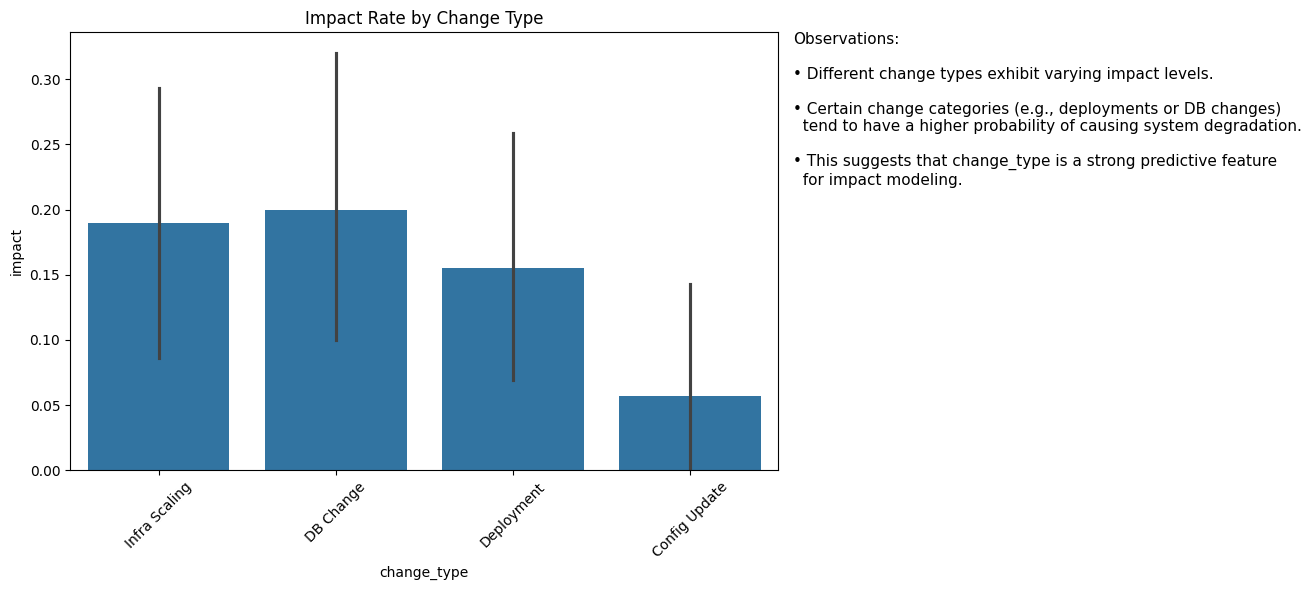

In [36]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)

sns.barplot(
    x="change_type",
    y="impact",
    data=impact_df,
    ax=ax1
)

ax1.set_title("Impact Rate by Change Type")
ax1.tick_params(axis='x', rotation=45)

eda_text = (
    "Observations:\n\n"
    "• Different change types exhibit varying impact levels.\n\n"
    "• Certain change categories (e.g., deployments or DB changes)\n"
    "  tend to have a higher probability of causing system degradation.\n\n"
    "• This suggests that change_type is a strong predictive feature\n"
    "  for impact modeling."
) 

ax2.axis("off")
ax2.text(0, 1, eda_text, fontsize=11, va="top")

plt.tight_layout()
plt.show()

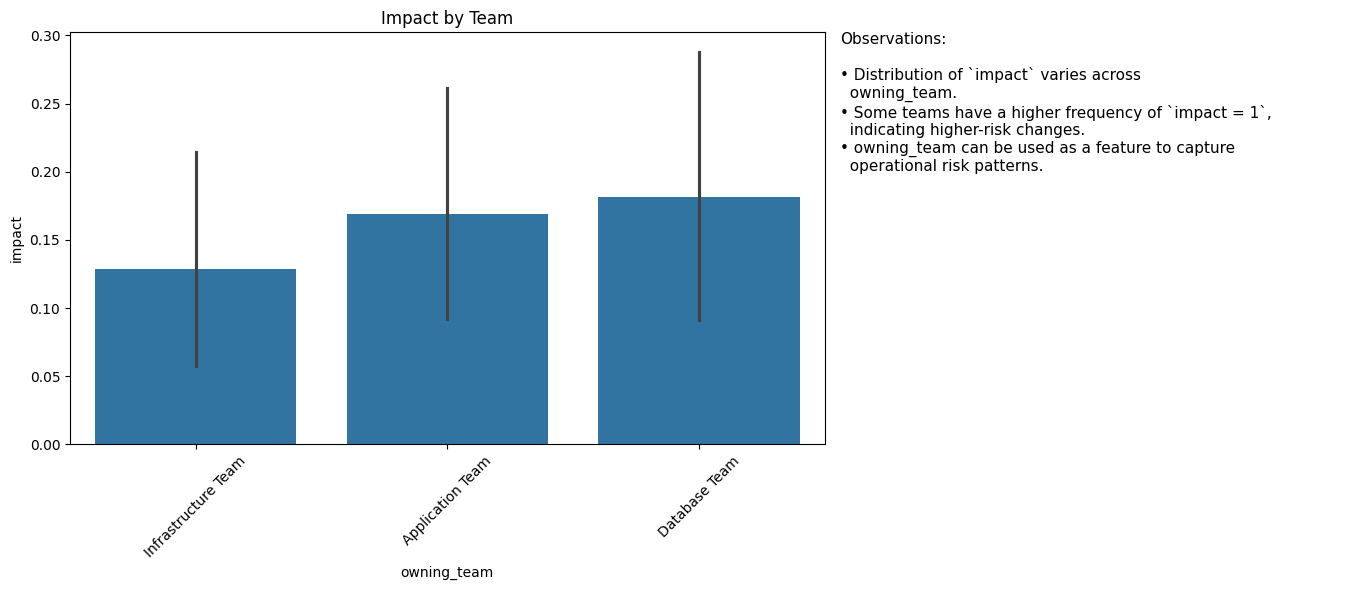

: 

In [ ]:
fig,(ax1,ax2)= plt.subplots(
    1,2,figsize=(14,6),
    gridspec_kw={'width_ratios': [3, 2]}
    )

sns.barplot(
    x="owning_team",
    y="impact",
    data=impact_df,
    ax=ax1
)
ax1.set_title("Impact by Team")
ax1.tick_params(axis='x', rotation=45)
eda_text = (
    "Observations:\n\n"
    "• Distribution of `impact` varies across \n"
    "  owning_team.\n"
    "• Some teams have a higher frequency of `impact = 1`,\n"
    "  indicating higher-risk changes.\n"
    "• owning_team can be used as a feature to capture \n"
    "  operational risk patterns.\n"
)
ax2.axis("off")
ax2.text(0,1,eda_text, fontsize=11, va="top")
plt.tight_layout()
plt.show()

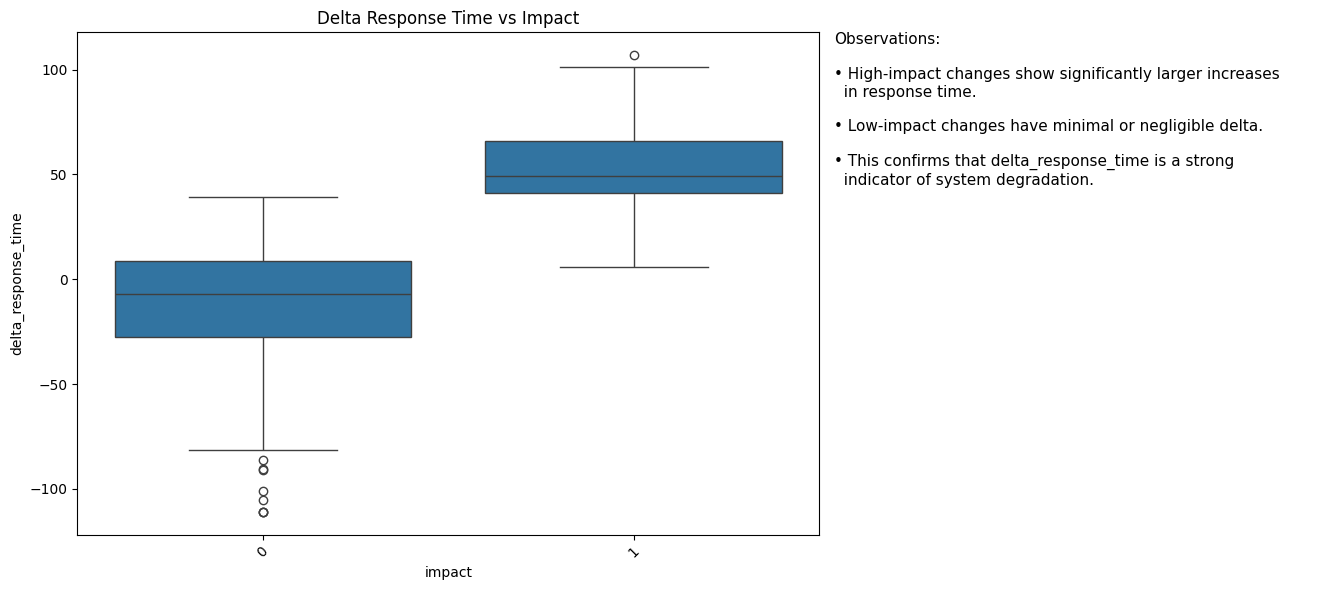

In [40]:
fig,(ax1,ax2)= plt.subplots(
    1,2,figsize=(14,6),
    gridspec_kw={'width_ratios': [3, 2]}
    )

sns.boxplot(
    x="impact",
    y="delta_response_time",
    data=impact_df,
    ax=ax1
)
ax1.set_title("Delta Response Time vs Impact")
ax1.tick_params(axis='x',rotation=45)
eda_text = (
    "Observations:\n\n"
    "• High-impact changes show significantly larger increases\n"
    "  in response time.\n\n"
    "• Low-impact changes have minimal or negligible delta.\n\n"
    "• This confirms that delta_response_time is a strong\n"
    "  indicator of system degradation."
)
ax2.axis("off")
ax2.text(0,1,eda_text,fontsize=11,va="top")
plt.tight_layout()
plt.show()

In [26]:
impact_df.corr(numeric_only=True)

,delta_response_time,delta_error_rate,delta_timeout,impact
delta_response_time,1.000000,0.831669,0.594710,0.609949
delta_error_rate,0.831669,1.000000,0.686722,0.621815
delta_timeout,0.594710,0.686722,1.000000,0.358194
impact,0.609949,0.621815,0.358194,1.000000


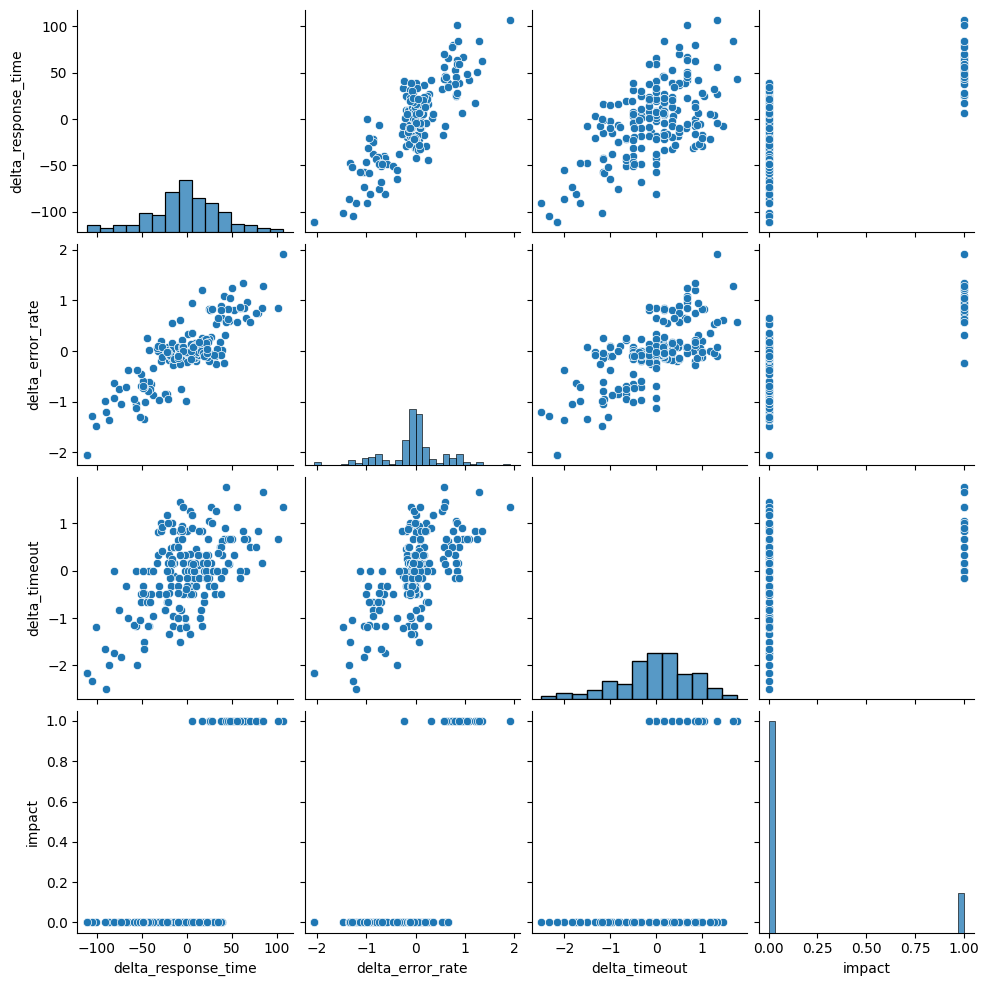

In [41]:
sns.pairplot(impact_df)


    Observations:
    • Strong correlation exists between response time error rate, and timeout count.
    • Weak correlation with CPU, memory, and throughput confirms that performance degradation is not resource-driven.
    • This supports the hypothesis that latency is failure-driven rather than load-induced."


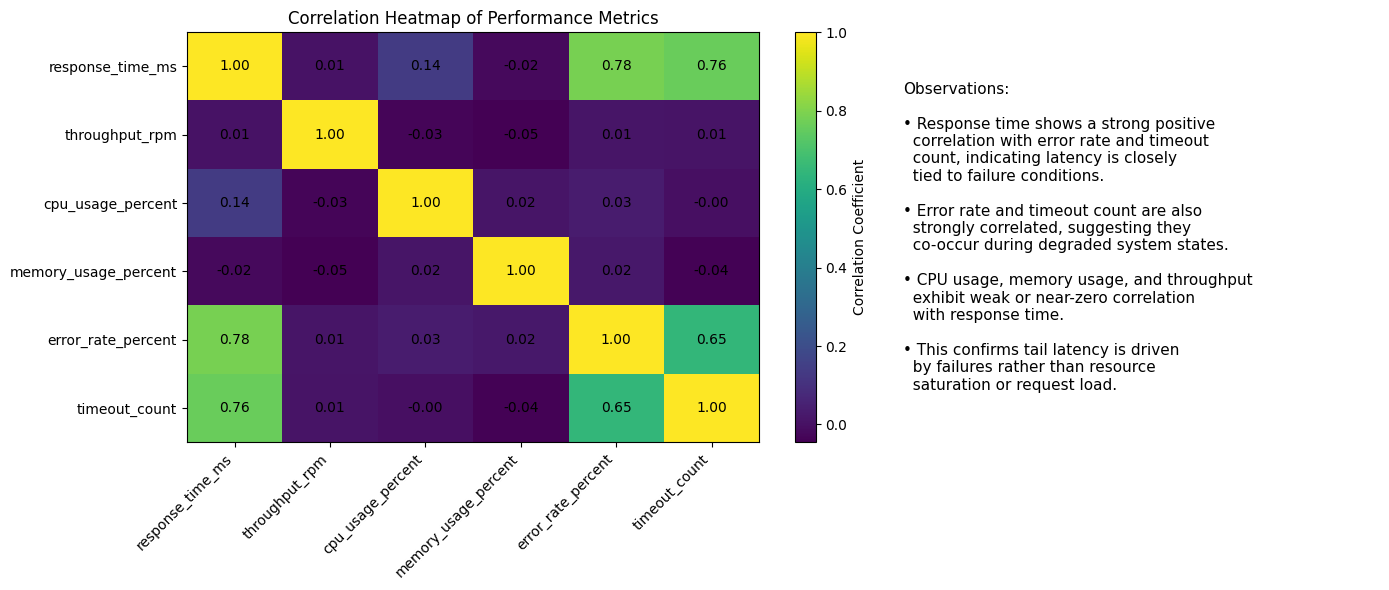

In [17]:
numeric_cols = [
    'response_time_ms',
    'throughput_rpm',
    'cpu_usage_percent',
    'memory_usage_percent',
    'error_rate_percent',
    'timeout_count'
]

corr = metrics_modified[numeric_cols].corr()

fig, (ax_heatmap, ax_text) = plt.subplots(
    ncols=2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)

# ---- Heatmap ----
im = ax_heatmap.imshow(corr, aspect='auto')
cbar = fig.colorbar(im, ax=ax_heatmap)
cbar.set_label('Correlation Coefficient')

ax_heatmap.set_xticks(range(len(corr.columns)))
ax_heatmap.set_yticks(range(len(corr.index)))

ax_heatmap.set_xticklabels(corr.columns, rotation=45, ha='right')
ax_heatmap.set_yticklabels(corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax_heatmap.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

ax_heatmap.set_title('Correlation Heatmap of Performance Metrics')

# ---- EDA Text ----
eda_text = (
    "Observations:\n\n"
    "• Response time shows a strong positive\n"
    "  correlation with error rate and timeout\n"
    "  count, indicating latency is closely\n"
    "  tied to failure conditions.\n\n"
    "• Error rate and timeout count are also\n"
    "  strongly correlated, suggesting they\n"
    "  co-occur during degraded system states.\n\n"
    "• CPU usage, memory usage, and throughput\n"
    "  exhibit weak or near-zero correlation\n"
    "  with response time.\n\n"
    "• This confirms tail latency is driven\n"
    "  by failures rather than resource\n"
    "  saturation or request load."
)

ax_text.axis('off')
ax_text.text(
    0,
    0.5,
    eda_text,
    fontsize=11,
    va='center'
)

plt.tight_layout()
plt.show()
